# 03. Analisis de Sentimiento

Analisis de sentimiento multilingual con `nlptown/bert-base-multilingual-uncased-sentiment` (BERT fine-tuned para clasificar textos en 1-5 estrellas).

**Datos analizados:**
- Comentarios Instagram (US + Europa)
- Comentarios TikTok (US + Europa)
- Reviews Trustpilot (Lululemon + ALO Yoga)

**Clasificacion:**
- 1-2 estrellas → Negativo
- 3 estrellas → Neutro
- 4-5 estrellas → Positivo

In [1]:
import sys
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentiment import predict_sentiment
from plotting import setup_style, save_fig, COLORS, PLATFORM_COLORS
setup_style()

DATA = "../../datos/clean"

In [2]:
ig_com = pd.read_csv(f"{DATA}/ig_comentarios.csv")
tk_com = pd.read_csv(f"{DATA}/tiktok_comentarios.csv")
tp = pd.read_csv(f"{DATA}/trustpilot_all.csv")

print(f"IG comentarios: {len(ig_com)}")
print(f"TK comentarios: {len(tk_com)}")
print(f"Trustpilot reviews: {len(tp)}")

IG comentarios: 1266
TK comentarios: 1056
Trustpilot reviews: 383


## 1. Sentimiento - Comentarios Instagram

In [3]:
print("Analizando sentimiento Instagram...")
ig_sent = predict_sentiment(ig_com["text_clean"].tolist())
ig_com = pd.concat([ig_com, ig_sent], axis=1)
print(f"Completado. Distribucion:")
print(ig_com["sentiment_label"].value_counts())

Analizando sentimiento Instagram...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Completado. Distribucion:
sentiment_label
positivo    608
negativo    481
neutro      177
Name: count, dtype: int64


## 2. Sentimiento - Comentarios TikTok

In [4]:
print("Analizando sentimiento TikTok...")
tk_sent = predict_sentiment(tk_com["text_clean"].tolist())
tk_com = pd.concat([tk_com, tk_sent], axis=1)
print(f"Completado. Distribucion:")
print(tk_com["sentiment_label"].value_counts())

Analizando sentimiento TikTok...


Completado. Distribucion:
sentiment_label
positivo    491
negativo    371
neutro      194
Name: count, dtype: int64


## 3. Sentimiento - Reviews Trustpilot

Trustpilot ya tiene rating explicito (1-5), pero analizamos el sentimiento del texto para comparar.

In [5]:
print("Analizando sentimiento Trustpilot...")
tp_sent = predict_sentiment(tp["text_clean"].tolist())
tp = pd.concat([tp, tp_sent], axis=1)

# Comparar rating real vs sentimiento predicho
tp["rating_label"] = pd.cut(tp["rating"], bins=[0, 2, 3, 5], labels=["negativo", "neutro", "positivo"])
concordancia = (tp["rating_label"] == tp["sentiment_label"]).mean()
print(f"\nConcordancia rating vs sentimiento BERT: {concordancia:.1%}")
print(f"\nDistribucion sentimiento BERT:")
print(tp["sentiment_label"].value_counts())

Analizando sentimiento Trustpilot...



Concordancia rating vs sentimiento BERT: 95.6%

Distribucion sentimiento BERT:
sentiment_label
negativo    349
positivo     29
neutro        5
Name: count, dtype: int64


## 4. Visualizacion del sentimiento por plataforma

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_por_plataforma.png


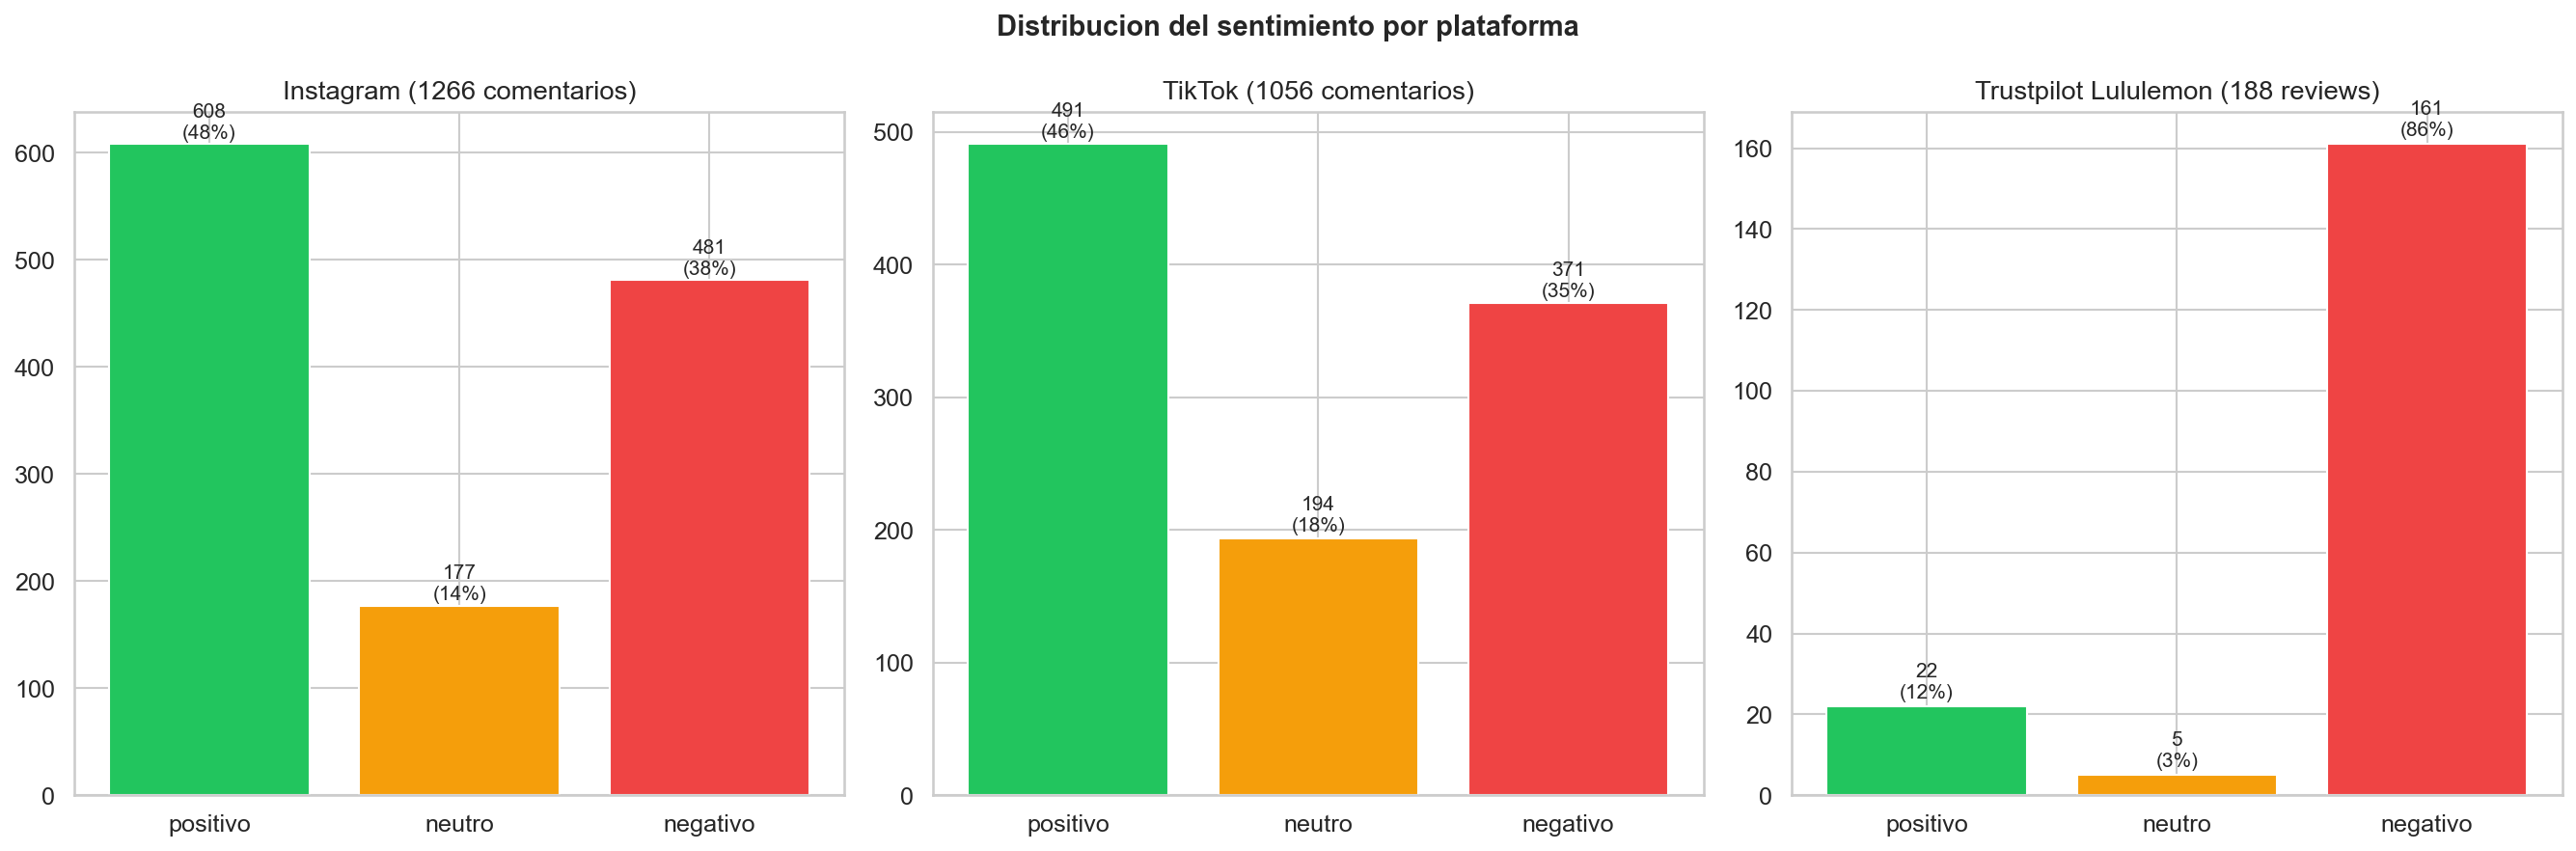

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sent_order = ["positivo", "neutro", "negativo"]
colors_sent = [COLORS["positive"], COLORS["neutral"], COLORS["negative"]]

# Instagram
ig_counts = ig_com["sentiment_label"].value_counts().reindex(sent_order)
axes[0].bar(sent_order, ig_counts.values, color=colors_sent)
axes[0].set_title(f"Instagram ({len(ig_com)} comentarios)")
for i, v in enumerate(ig_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({v/len(ig_com)*100:.0f}%)", ha="center", fontsize=10)

# TikTok
tk_counts = tk_com["sentiment_label"].value_counts().reindex(sent_order)
axes[1].bar(sent_order, tk_counts.values, color=colors_sent)
axes[1].set_title(f"TikTok ({len(tk_com)} comentarios)")
for i, v in enumerate(tk_counts.values):
    axes[1].text(i, v + 5, f"{v}\n({v/len(tk_com)*100:.0f}%)", ha="center", fontsize=10)

# Trustpilot
tp_lulu = tp[tp["brand"] == "Lululemon"]
tp_counts = tp_lulu["sentiment_label"].value_counts().reindex(sent_order)
axes[2].bar(sent_order, tp_counts.values, color=colors_sent)
axes[2].set_title(f"Trustpilot Lululemon ({len(tp_lulu)} reviews)")
for i, v in enumerate(tp_counts.values):
    axes[2].text(i, v + 2, f"{v}\n({v/len(tp_lulu)*100:.0f}%)", ha="center", fontsize=10)

plt.suptitle("Distribucion del sentimiento por plataforma", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "sent_por_plataforma")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_estrellas_detalle.png


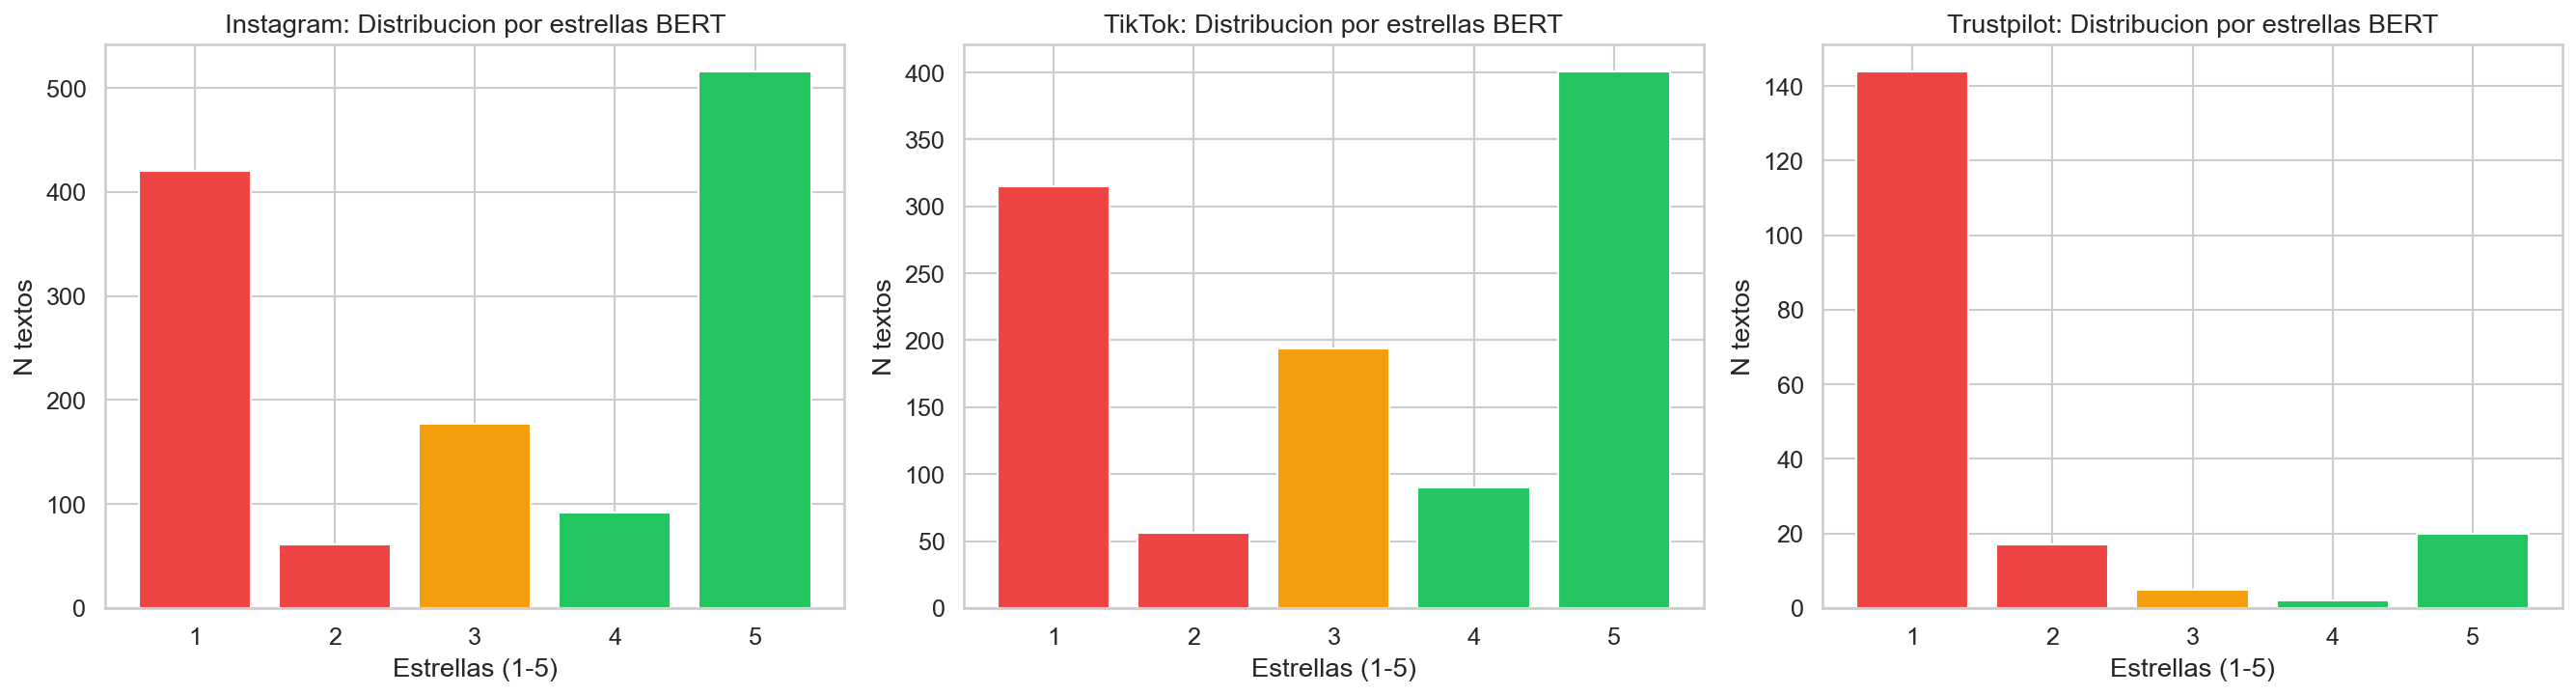

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df) in zip(axes, [("Instagram", ig_com), ("TikTok", tk_com), ("Trustpilot", tp_lulu)]):
    stars_dist = df["sentiment_stars"].value_counts().sort_index()
    ax.bar(stars_dist.index, stars_dist.values, color=[COLORS["negative"], COLORS["negative"],
           COLORS["neutral"], COLORS["positive"], COLORS["positive"]])
    ax.set_title(f"{label}: Distribucion por estrellas BERT")
    ax.set_xlabel("Estrellas (1-5)")
    ax.set_ylabel("N textos")
    ax.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
save_fig(fig, "sent_estrellas_detalle")
plt.show()

## 5. Que dicen los comentarios negativos?

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_wordcloud_negativos.png


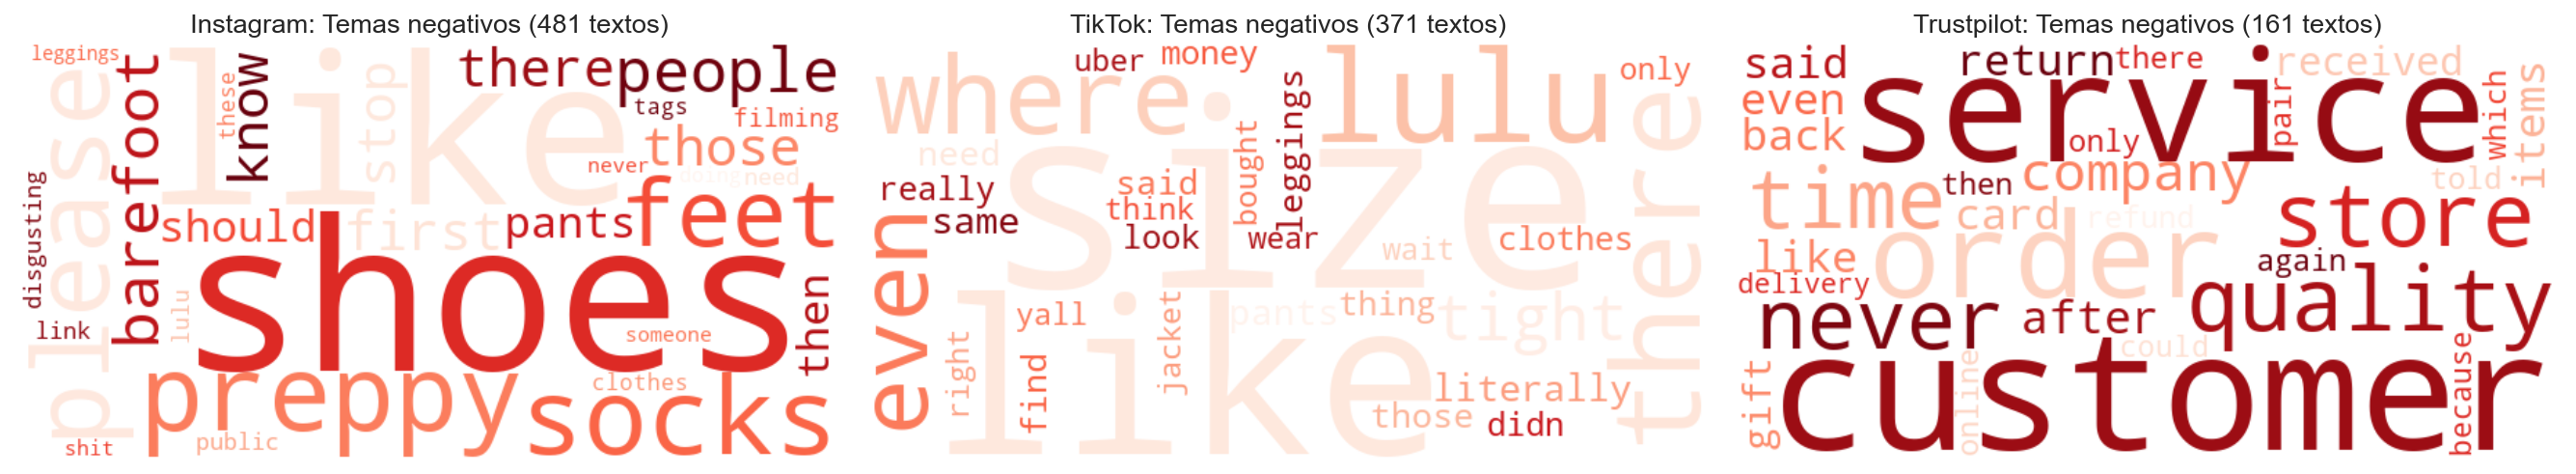

In [8]:
from wordcloud import WordCloud
from collections import Counter
import re

def get_top_words(texts, n=30, min_len=4):
    stopwords = {"this", "that", "with", "have", "from", "they", "them", "their", "your", "would",
                 "been", "were", "will", "just", "more", "como", "para", "pero", "este", "esta",
                 "very", "much", "also", "about", "what", "when", "than", "some", "lululemon", "the"}
    words = []
    for text in texts:
        if pd.isna(text):
            continue
        tokens = re.findall(r'\b[a-zA-Z\u00e1\u00e9\u00ed\u00f3\u00fa\u00f1\u00fc]+\b', str(text).lower())
        words.extend([w for w in tokens if len(w) >= min_len and w not in stopwords])
    return Counter(words).most_common(n)

# Comentarios negativos por plataforma
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df) in zip(axes, [("Instagram", ig_com), ("TikTok", tk_com), ("Trustpilot", tp_lulu)]):
    neg_texts = df[df["sentiment_label"] == "negativo"]["text_clean"]
    if len(neg_texts) > 5:
        wc_data = dict(get_top_words(neg_texts))
        wc = WordCloud(width=600, height=300, background_color="white",
                       colormap="Reds").generate_from_frequencies(wc_data)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{label}: Temas negativos ({len(neg_texts)} textos)")

plt.tight_layout()
save_fig(fig, "sent_wordcloud_negativos")
plt.show()

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_wordcloud_positivos.png


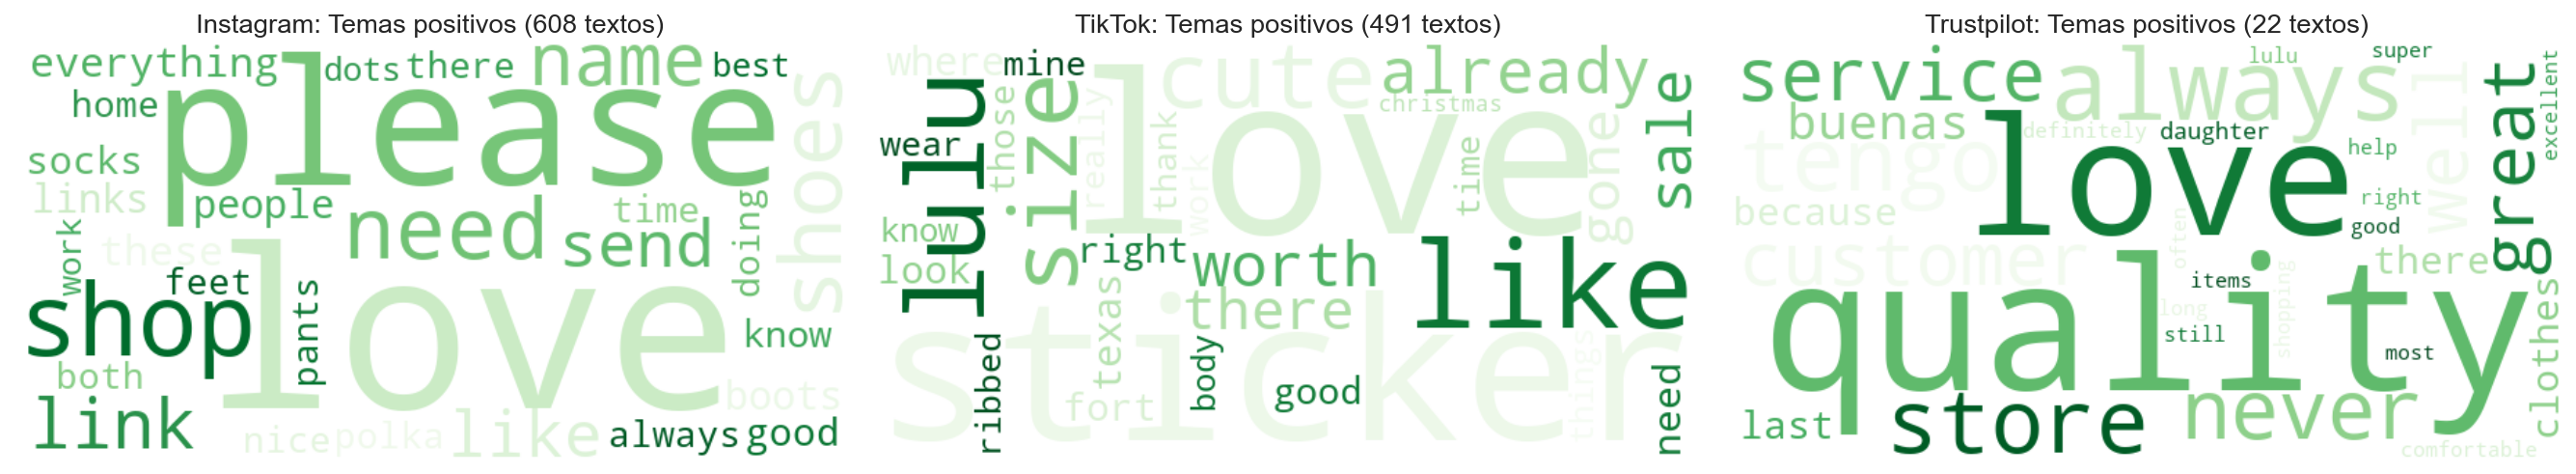

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df) in zip(axes, [("Instagram", ig_com), ("TikTok", tk_com), ("Trustpilot", tp_lulu)]):
    pos_texts = df[df["sentiment_label"] == "positivo"]["text_clean"]
    if len(pos_texts) > 5:
        wc_data = dict(get_top_words(pos_texts))
        wc = WordCloud(width=600, height=300, background_color="white",
                       colormap="Greens").generate_from_frequencies(wc_data)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{label}: Temas positivos ({len(pos_texts)} textos)")

plt.tight_layout()
save_fig(fig, "sent_wordcloud_positivos")
plt.show()

## 6. Topic Modeling (LDA)

Extraccion automatica de topicos latentes en los comentarios y reviews usando Latent Dirichlet Allocation.

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Combinar todos los textos con metadatos
all_texts = pd.concat([
    ig_com[["text_clean", "sentiment_label", "sentiment_stars", "region"]].assign(platform="instagram"),
    tk_com[["text_clean", "sentiment_label", "sentiment_stars", "region_search"]].rename(columns={"region_search": "region"}).assign(platform="tiktok"),
    tp[tp["brand"]=="Lululemon"][["text_clean", "sentiment_label", "sentiment_stars", "country"]].rename(columns={"country": "region"}).assign(platform="trustpilot"),
], ignore_index=True)

# Filtrar textos muy cortos
all_texts = all_texts[all_texts["text_clean"].str.len() >= 15].reset_index(drop=True)
print(f"Textos para LDA: {len(all_texts)}")

# Stopwords multilingue
STOPWORDS_CUSTOM = [
    "the", "and", "for", "that", "this", "with", "you", "your", "are", "was", "have", "has",
    "from", "they", "them", "their", "would", "been", "were", "will", "just", "more", "also",
    "about", "what", "when", "than", "some", "like", "really", "very", "much", "know", "think",
    "love", "want", "need", "get", "got", "one", "can", "don", "not", "but", "all", "out",
    "que", "los", "las", "del", "una", "con", "por", "para", "como", "pero", "mas", "sus",
    "este", "esta", "estos", "estas", "todo", "muy", "bien", "hay", "ser", "tiene", "desde",
    "les", "des", "une", "pas", "pour", "dans", "sur", "avec", "est", "sont", "plus",
    "tres", "cette", "ces", "tout", "fait", "aussi", "comme",
    "und", "die", "der", "das", "ist", "nicht", "ein", "eine", "den", "dem", "auf", "mit",
    "ich", "sie", "sich", "von", "auch", "noch", "aber", "hat", "nur", "sehr",
    "lululemon", "lulu", "yoga", "http", "https", "www", "com",
]

vectorizer = CountVectorizer(
    max_df=0.85, min_df=5, max_features=2000,
    stop_words=STOPWORDS_CUSTOM,
    token_pattern=r'\b[a-zA-Z\u00e1\u00e9\u00ed\u00f3\u00fa\u00f1\u00fc\u00e0\u00e8\u00ec\u00f2\u00f9\u00e2\u00ea\u00ee\u00f4\u00fb\u00e4\u00eb\u00ef\u00f6\u00fc]{3,}\b',
)

dtm = vectorizer.fit_transform(all_texts["text_clean"])
feature_names = vectorizer.get_feature_names_out()
print(f"Vocabulario: {len(feature_names)} terminos")
print(f"Matriz doc-term: {dtm.shape}")

Textos para LDA: 2061
Vocabulario: 747 terminos
Matriz doc-term: (2061, 747)


In [11]:
N_TOPICS = 8

lda = LatentDirichletAllocation(
    n_components=N_TOPICS, random_state=42, max_iter=20,
    learning_method="online", n_jobs=-1,
)

lda_output = lda.fit_transform(dtm)

def print_topics(model, feature_names, n_top_words=12):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics[f"Topico {idx+1}"] = top_words
        print(f"Topico {idx+1}: {', '.join(top_words)}")
    return topics

print(f"=== {N_TOPICS} Topicos LDA ===\n")
topics_dict = print_topics(lda, feature_names)

=== 8 Topicos LDA ===

Topico 1: even, return, people, now, months, those, fit, buy, black, let, great, cost
Topico 2: customer, service, back, never, refund, company, order, time, received, pants, only, said
Topico 3: wear, didn, same, day, find, always, see, here, barefoot, years, wearing, asked
Topico 4: gym, shoes, worth, where, put, feet, socks, zero, gone, sale, stop, since
Topico 5: quality, she, store, clothes, online, then, way, her, already, who, cheap, paid
Topico 6: did, leggings, told, could, made, lol, shipping, come, jacket, these, expensive, into
Topico 7: how, why, bag, better, there, good, work, using, feel, make, everything, trying
Topico 8: had, size, there, off, money, which, look, please, right, products, gift, preppy


Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_lda_topicos.png


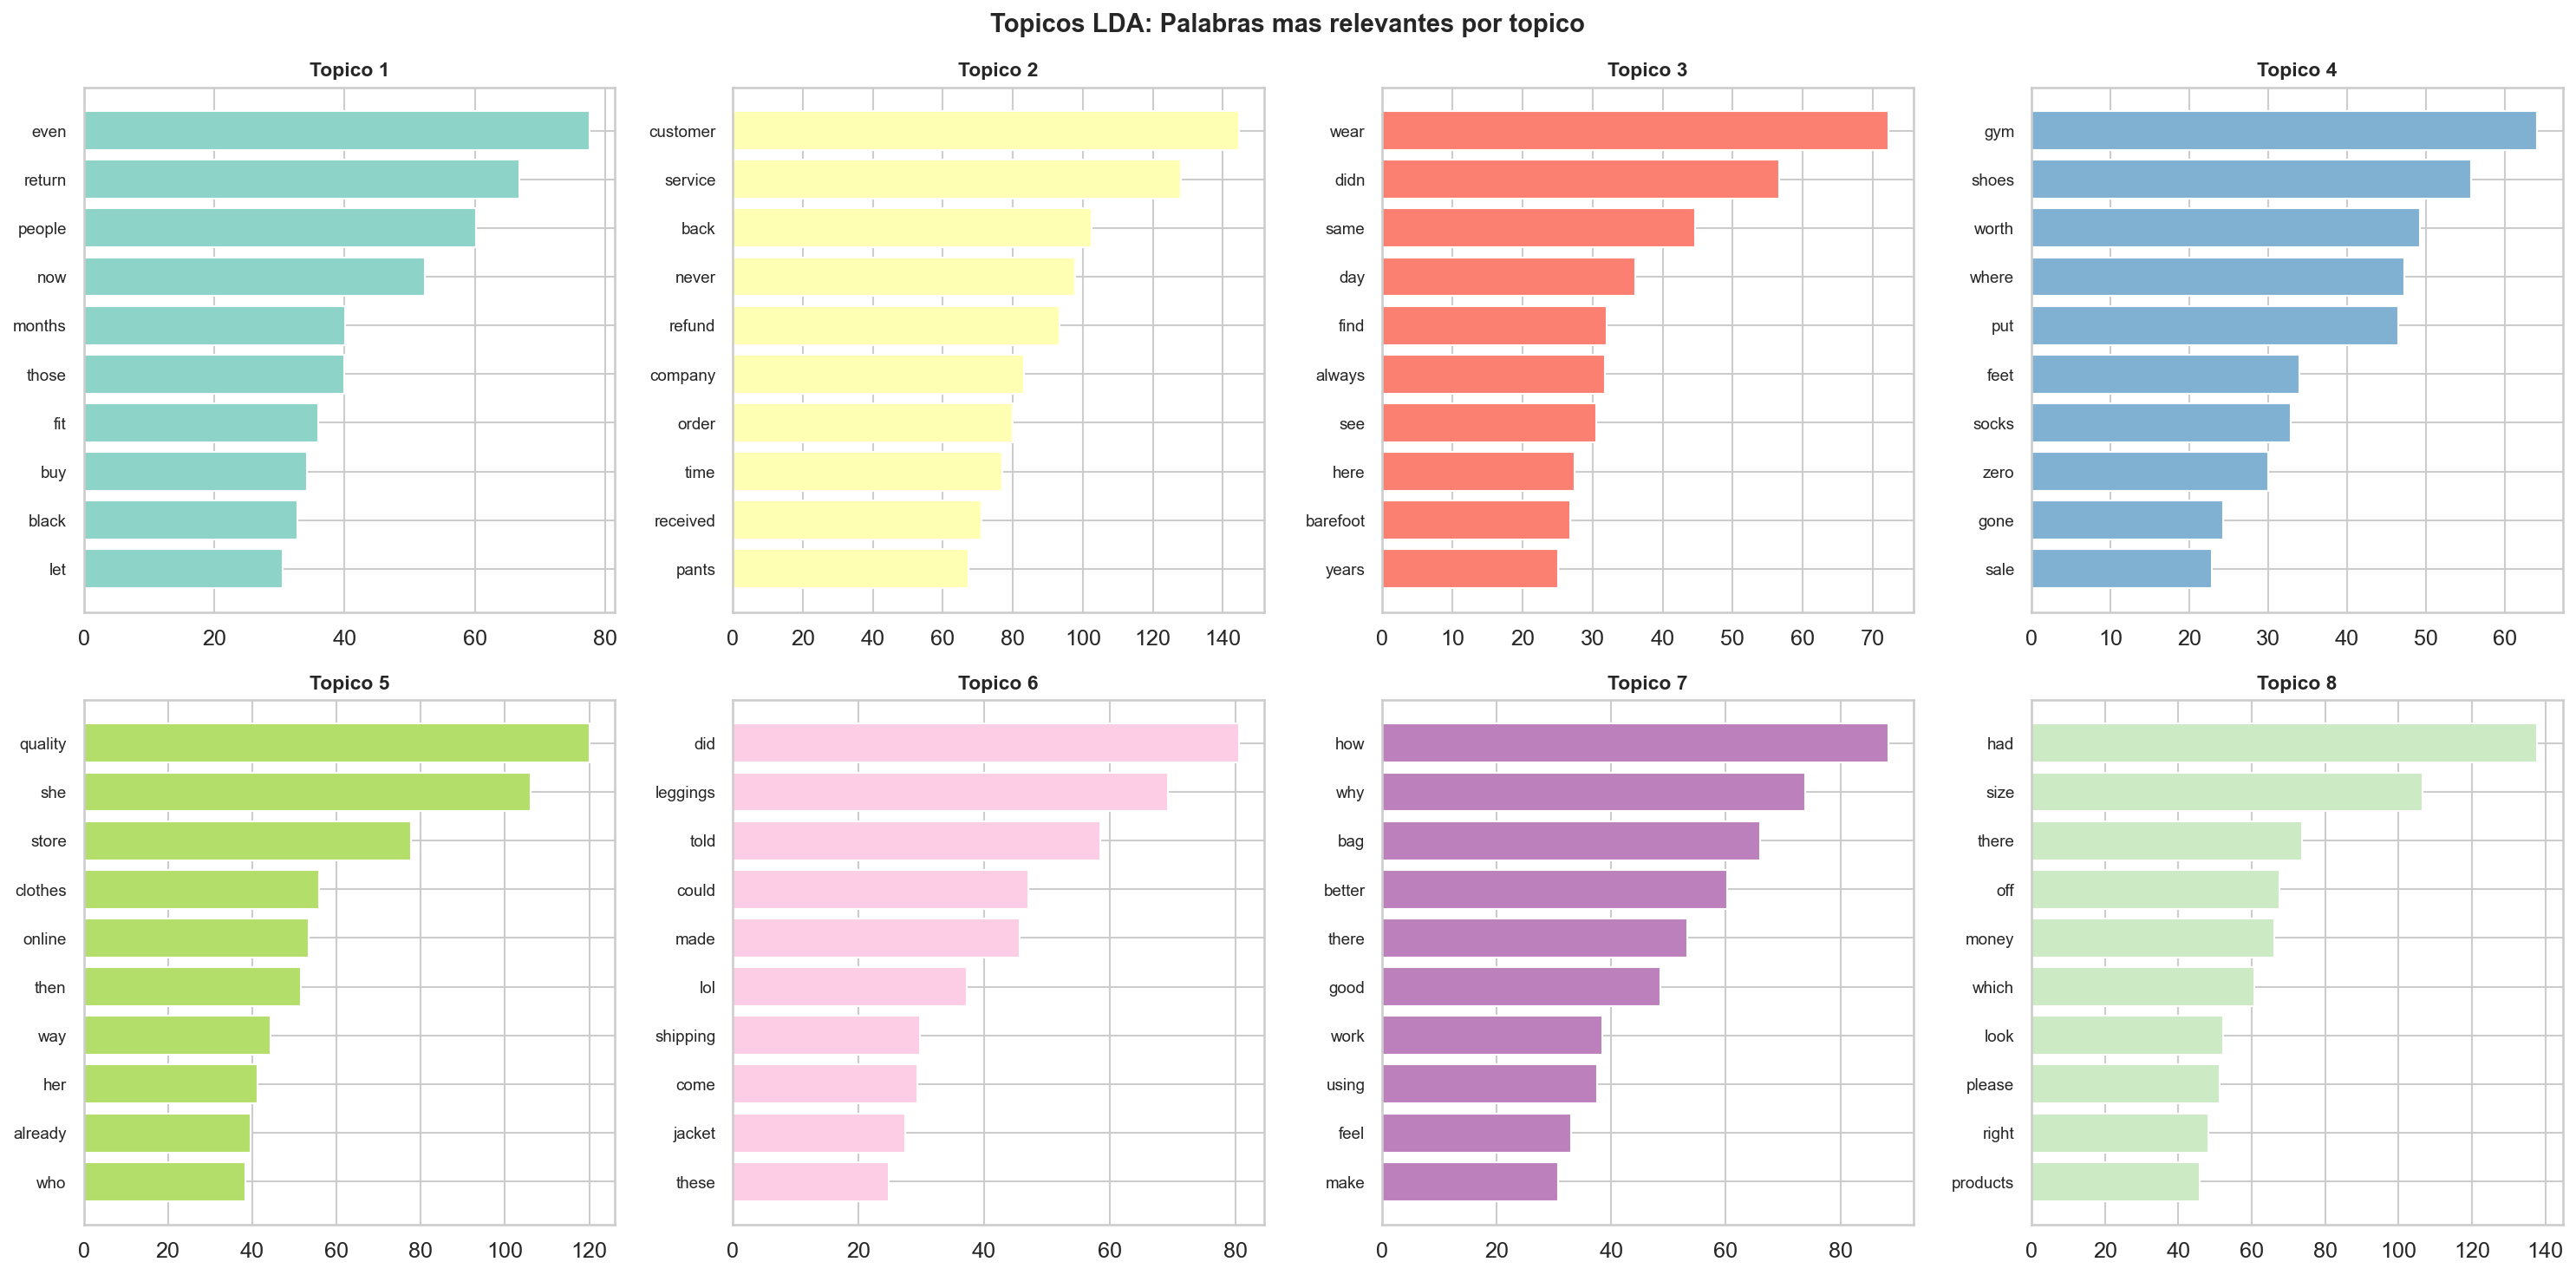

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, ax in enumerate(axes.flat):
    if idx >= N_TOPICS:
        ax.axis("off")
        continue
    top_indices = lda.components_[idx].argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = [lda.components_[idx][i] for i in top_indices]

    ax.barh(top_words[::-1], top_weights[::-1], color=plt.cm.Set3(idx / N_TOPICS))
    ax.set_title(f"Topico {idx+1}", fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Topicos LDA: Palabras mas relevantes por topico", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "sent_lda_topicos")
plt.show()

In [13]:
all_texts["topico_dominante"] = lda_output.argmax(axis=1) + 1
all_texts["topico_prob"] = lda_output.max(axis=1)

print("Distribucion de topicos:")
print(all_texts["topico_dominante"].value_counts().sort_index())

Distribucion de topicos:
topico_dominante
1    376
2    287
3    203
4    239
5    210
6    187
7    271
8    288
Name: count, dtype: int64


### 6.1 Topicos por sentimiento

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_lda_topicos_x_sentimiento.png


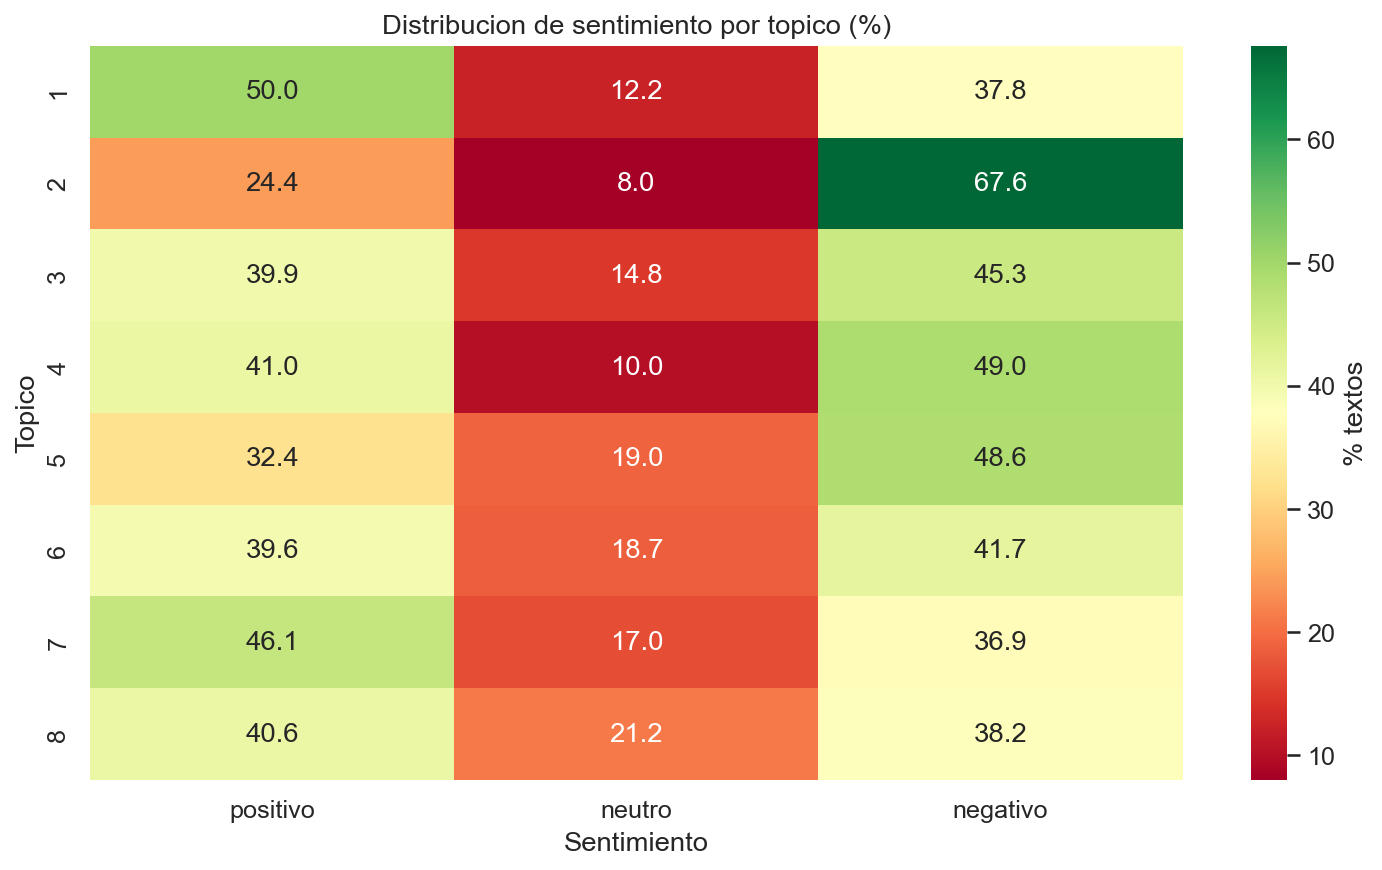


Topicos ordenados por % negativo:


,n,sent_media,pct_negativo,pct_positivo,top_words
topico_dominante,,,,,
2,287,2.2,67.6,24.4,"customer, service, back, never, refund"
4,239,2.8,49.0,41.0,"gym, shoes, worth, where, put"
5,210,2.7,48.6,32.4,"quality, she, store, clothes, online"
3,203,2.9,45.3,39.9,"wear, didn, same, day, find"
6,187,3.0,41.7,39.6,"did, leggings, told, could, made"
8,288,3.0,38.2,40.6,"had, size, there, off, money"
1,376,3.2,37.8,50.0,"even, return, people, now, months"
7,271,3.2,36.9,46.1,"how, why, bag, better, there"


In [14]:
cross = pd.crosstab(all_texts["topico_dominante"], all_texts["sentiment_label"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cross[["positivo", "neutro", "negativo"]], annot=True, fmt=".1f", cmap="RdYlGn",
            ax=ax, cbar_kws={"label": "% textos"})
ax.set_title("Distribucion de sentimiento por topico (%)")
ax.set_ylabel("Topico")
ax.set_xlabel("Sentimiento")
plt.tight_layout()
save_fig(fig, "sent_lda_topicos_x_sentimiento")
plt.show()

topic_sentiment = all_texts.groupby("topico_dominante").agg(
    n=("text_clean", "count"),
    sent_media=("sentiment_stars", "mean"),
    pct_negativo=("sentiment_label", lambda x: (x == "negativo").mean() * 100),
    pct_positivo=("sentiment_label", lambda x: (x == "positivo").mean() * 100),
).round(1)

topic_sentiment["top_words"] = topic_sentiment.index.map(
    lambda t: ", ".join(topics_dict.get(f"Topico {t}", [])[:5])
)

print("\nTopicos ordenados por % negativo:")
display(topic_sentiment.sort_values("pct_negativo", ascending=False))

### 6.2 Topicos por region (US vs Europa)

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_lda_topicos_x_region.png


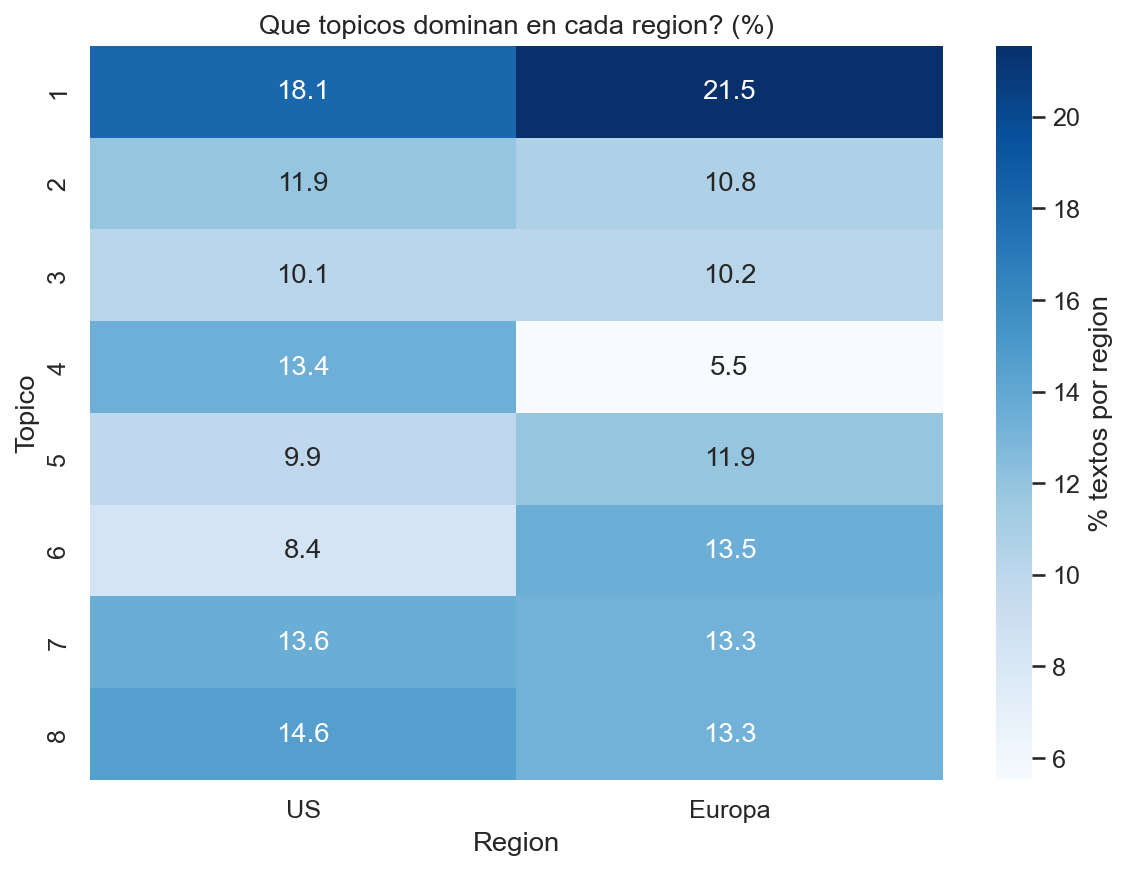

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_lda_diferencia_eu_vs_us.png


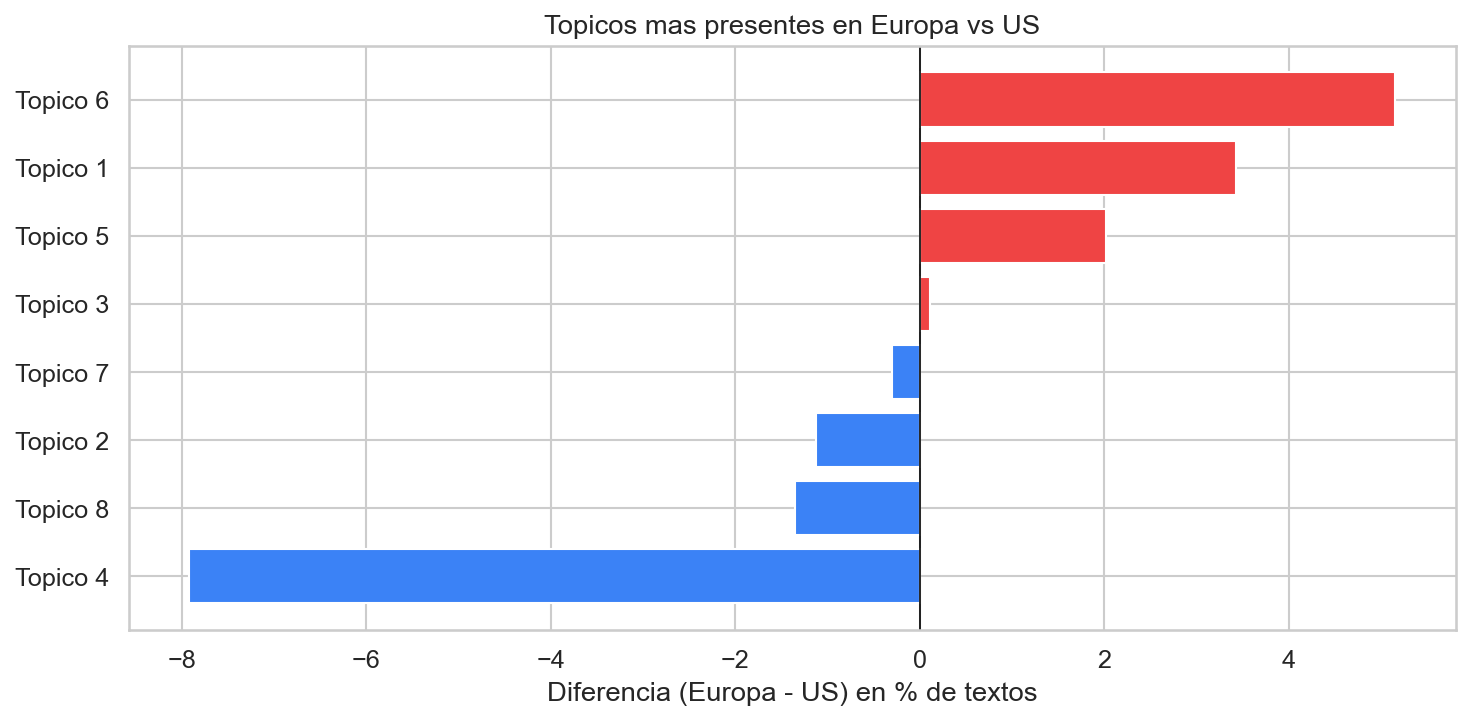

In [15]:
def simplify_region(r):
    if r in ["US", "US/GB"]:
        return "US"
    elif r in ["Europe", "ES", "FR", "GB", "DE"]:
        return "Europa"
    return "Otro"

all_texts["region_simple"] = all_texts["region"].apply(simplify_region)

cross_region = pd.crosstab(all_texts["topico_dominante"],
                            all_texts["region_simple"], normalize="columns") * 100

fig, ax = plt.subplots(figsize=(8, 6))
cross_region_plot = cross_region[["US", "Europa"]].copy() if "Europa" in cross_region.columns else cross_region
sns.heatmap(cross_region_plot, annot=True, fmt=".1f", cmap="Blues", ax=ax,
            cbar_kws={"label": "% textos por region"})
ax.set_title("Que topicos dominan en cada region? (%)")
ax.set_ylabel("Topico")
ax.set_xlabel("Region")
plt.tight_layout()
save_fig(fig, "sent_lda_topicos_x_region")
plt.show()

if "US" in cross_region.columns and "Europa" in cross_region.columns:
    diff = (cross_region["Europa"] - cross_region["US"]).sort_values()
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [COLORS["europe"] if v > 0 else COLORS["us"] for v in diff.values]
    ax.barh([f"Topico {i}" for i in diff.index], diff.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Diferencia (Europa - US) en % de textos")
    ax.set_title("Topicos mas presentes en Europa vs US")
    plt.tight_layout()
    save_fig(fig, "sent_lda_diferencia_eu_vs_us")
    plt.show()

### 6.3 Topicos por plataforma

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/sent_lda_topicos_x_plataforma.png


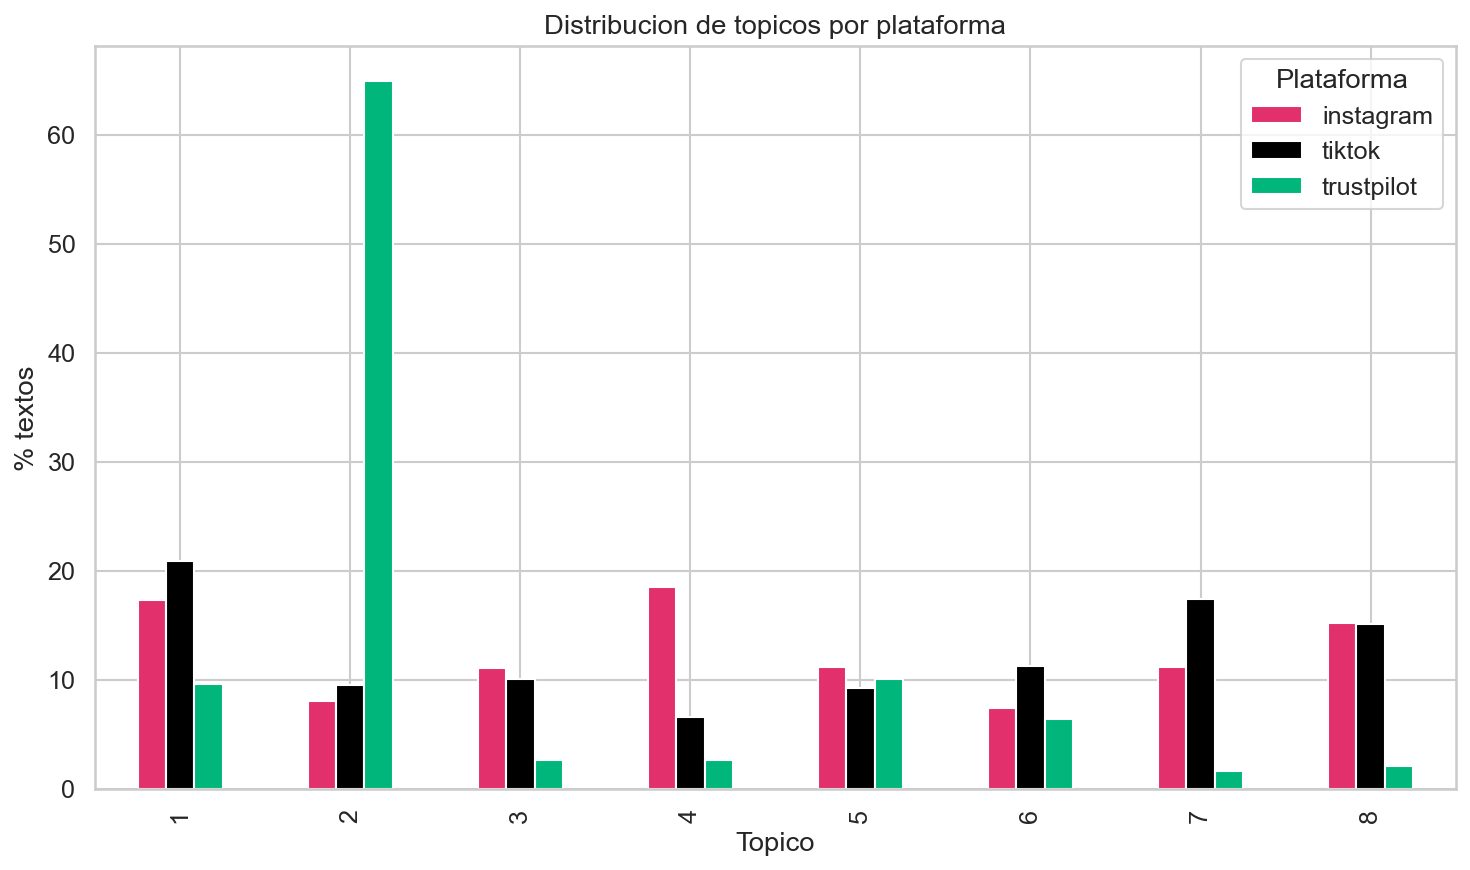

Topicos guardados en outputs/tablas/


In [16]:
cross_plat = pd.crosstab(all_texts["topico_dominante"],
                          all_texts["platform"], normalize="columns") * 100

fig, ax = plt.subplots(figsize=(10, 6))
cross_plat.plot(kind="bar", ax=ax, color=[PLATFORM_COLORS.get(p, "#999") for p in cross_plat.columns])
ax.set_title("Distribucion de topicos por plataforma")
ax.set_xlabel("Topico")
ax.set_ylabel("% textos")
ax.legend(title="Plataforma")
plt.tight_layout()
save_fig(fig, "sent_lda_topicos_x_plataforma")
plt.show()

# Guardar topicos
topics_df = pd.DataFrame(topics_dict)
topics_df.index = [f"Palabra {i+1}" for i in range(len(topics_df))]
topics_df.to_csv("../../outputs/tablas/sent_lda_topicos.csv")
topic_sentiment.to_csv("../../outputs/tablas/sent_lda_topicos_sentimiento.csv")
print("Topicos guardados en outputs/tablas/")

## 7. Guardar datos con sentimiento y topicos

In [17]:
ig_com.to_csv(f"{DATA}/ig_comentarios_sentiment.csv", index=False, encoding="utf-8-sig")
tk_com.to_csv(f"{DATA}/tiktok_comentarios_sentiment.csv", index=False, encoding="utf-8-sig")
tp.to_csv(f"{DATA}/trustpilot_all_sentiment.csv", index=False, encoding="utf-8-sig")
all_texts.to_csv(f"{DATA}/all_texts_sentiment_topics.csv", index=False, encoding="utf-8-sig")

tp_lulu = tp[tp["brand"] == "Lululemon"]
resumen_sent = pd.DataFrame({
    "Plataforma": ["Instagram", "TikTok", "Trustpilot Lulu", "Trustpilot ALO"],
    "N textos": [len(ig_com), len(tk_com), len(tp_lulu), len(tp[tp["brand"]=="ALO Yoga"])],
    "% Positivo": [
        f"{(ig_com['sentiment_label']=='positivo').mean()*100:.1f}%",
        f"{(tk_com['sentiment_label']=='positivo').mean()*100:.1f}%",
        f"{(tp_lulu['sentiment_label']=='positivo').mean()*100:.1f}%",
        f"{(tp[tp['brand']=='ALO Yoga']['sentiment_label']=='positivo').mean()*100:.1f}%",
    ],
    "% Negativo": [
        f"{(ig_com['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{(tk_com['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{(tp_lulu['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{(tp[tp['brand']=='ALO Yoga']['sentiment_label']=='negativo').mean()*100:.1f}%",
    ],
    "Media estrellas": [
        f"{ig_com['sentiment_stars'].mean():.2f}",
        f"{tk_com['sentiment_stars'].mean():.2f}",
        f"{tp_lulu['sentiment_stars'].mean():.2f}",
        f"{tp[tp['brand']=='ALO Yoga']['sentiment_stars'].mean():.2f}",
    ],
})

resumen_sent.to_csv("../../outputs/tablas/sent_resumen.csv", index=False)
resumen_sent

,Plataforma,N textos,% Positivo,% Negativo,Media estrellas
0,Instagram,1266,48.0%,38.0%,3.18
1,TikTok,1056,46.5%,35.1%,3.20
2,Trustpilot Lulu,188,11.7%,85.6%,1.60
3,Trustpilot ALO,195,3.6%,96.4%,1.23
